Dataset-ul conține temperatura zilnică (°C) și vânzările de înghețată (unități) pentru o gelaterie din București pe parcursul unui an întreg, cu peste 200 de înregistrări.
1. Trebuie creat un scatter plot pentru a vizualiza relația dintre temperatură și vânzări.
2. Trebuie să separi datele în variabila independentă (X) și variabila dependentă (y). Variabila independentă este temperatura, iar variabila dependentă este numărul de vânzări.
3. Creează un model și antrenează-l pe datele de antrenament.
4. Folosește modelul pentru a prezice vânzările pentru temperaturi noi pe care nu le-ai văzut înainte.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

In [2]:
df = pd.read_csv("datasets/date_inghetata.csv")
df

,temperatura,vanzari,luna,zi_saptamana
0,8,25,ianuarie,luni
1,10,35,ianuarie,marti
2,12,45,ianuarie,miercuri
3,15,55,ianuarie,joi
4,18,75,ianuarie,vineri
...,...,...,...,...
233,33,168,mai,miercuri
234,35,182,mai,joi
235,37,195,mai,vineri
236,39,208,mai,sambata


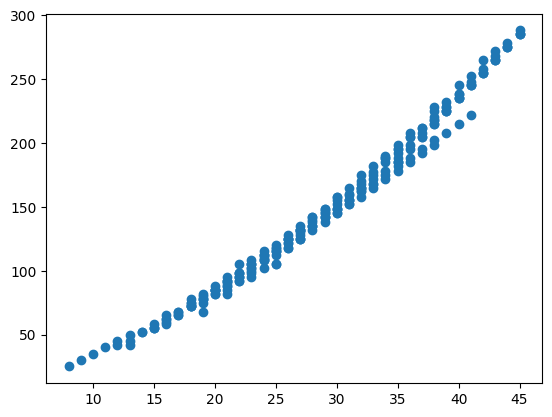

In [4]:
plt.scatter(df["temperatura"], df["vanzari"]);

In [ ]:
x = df[["temperatura"]]
y = df["vanzari"]


all_model = [LinearRegression(), DecisionTreeRegressor(), KNeighborsRegressor()]

for model in all_model:
    model.fit(x, y)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


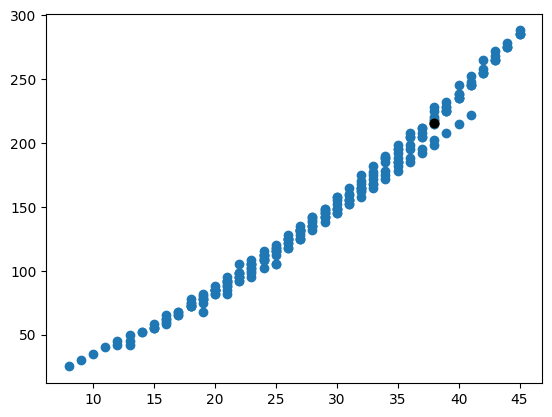

In [12]:
plt.scatter(df["temperatura"], df["vanzari"]);
new_temp = 38

for model, color in zip(all_model, ("red", "green", "black")):
    predicted_value = model.predict([[new_temp]])
    plt.scatter(new_temp, predicted_value, c=color);

# Folosind train test split

In [15]:
from sklearn.model_selection import train_test_split

In [19]:
x = df[["temperatura"]]
y = df["vanzari"]
x_train, x_test, y_train, y_test = train_test_split(x, y)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((178, 1), (60, 1), (178,), (60,))

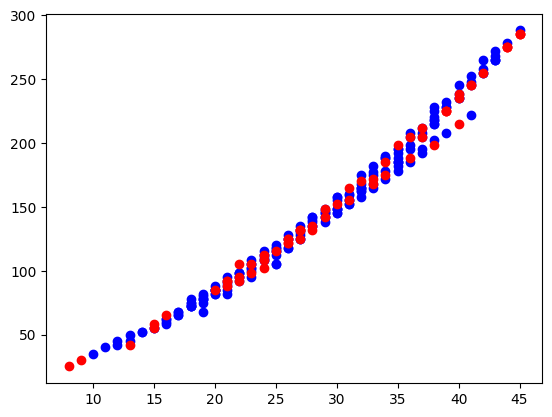

In [20]:
plt.scatter(x_train, y_train, c="blue");
plt.scatter(x_test, y_test, c="red")

In [21]:
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
model.score(x_test, y_test)

0.9790739113182365